In [5]:
import scipy.io
data = scipy.io.loadmat('Xtrain.mat')
print(type(data))
data

<class 'dict'>


{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Apr 29 11:11:31 2019',
 '__version__': '1.0',
 '__globals__': [],
 'Xtrain': array([[ 86],
        [141],
        [ 95],
        [ 41],
        [ 22],
        [ 21],
        [ 32],
        [ 72],
        [138],
        [111],
        [ 48],
        [ 23],
        [ 19],
        [ 27],
        [ 59],
        [129],
        [129],
        [ 58],
        [ 27],
        [ 19],
        [ 24],
        [ 46],
        [112],
        [144],
        [ 73],
        [ 30],
        [ 20],
        [ 19],
        [ 37],
        [ 92],
        [152],
        [ 93],
        [ 36],
        [ 20],
        [ 18],
        [ 29],
        [ 71],
        [146],
        [117],
        [ 46],
        [ 23],
        [ 18],
        [ 22],
        [ 52],
        [128],
        [142],
        [ 62],
        [ 26],
        [ 17],
        [ 19],
        [ 37],
        [100],
        [158],
        [ 86],
        [ 32],
        [ 17],
        [ 1

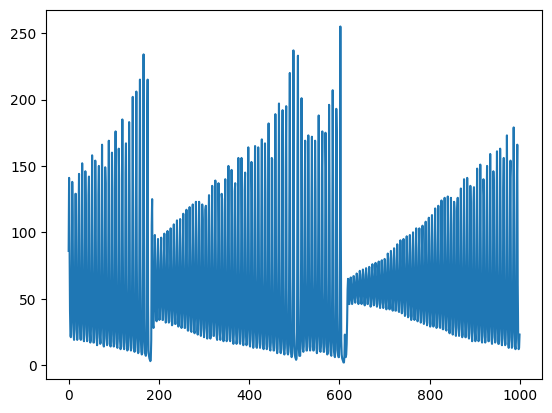

In [11]:
import matplotlib.pyplot as plt
plt.plot(data["Xtrain"])
plt.show()

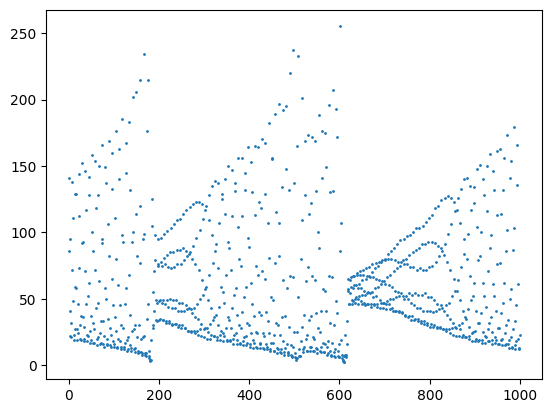

In [14]:
plt.scatter(y=data["Xtrain"], x=range(len(data["Xtrain"])), s=1)
plt.show()

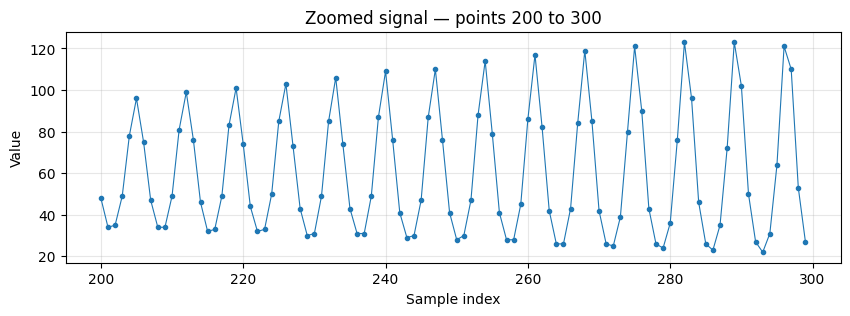

In [ ]:
# Zoom helper: set start/end to choose the range to plot,
start = 200
end = 300

# ensure data is a 1D array
y = data['Xtrain'].squeeze()

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.plot(range(start, end), y[start:end], marker='.', linewidth=0.8)
plt.title(f'Zoomed signal — points {start} to {end}')
plt.xlabel('Sample index')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.show()

## Fast Fourier Transform

Loaded signal: 1000 points  |  min=2.000  max=255.000

Top 10 frequency components:
Rank   Bin    Cycles/window    Amplitude    Phase (rad)
----------------------------------------------------------
1      0      0.0000           59.8940      0.0000   (DC offset)
2      136    0.1360           23.9097      -1.1214   (period ≈ 7.4 pts)
3      138    0.1380           17.4431      -0.1716   (period ≈ 7.2 pts)
4      135    0.1350           16.8768      0.0250   (period ≈ 7.4 pts)
5      133    0.1330           15.8001      0.2313   (period ≈ 7.5 pts)
6      129    0.1290           15.3518      -2.4926   (period ≈ 7.8 pts)
7      127    0.1270           14.9192      -1.8360   (period ≈ 7.9 pts)
8      134    0.1340           14.1290      -1.4088   (period ≈ 7.5 pts)
9      126    0.1260           13.1470      0.7929   (period ≈ 7.9 pts)
10     140    0.1400           12.3325      2.3229   (period ≈ 7.1 pts)

Fit quality (top 10 components over 1000 points):
  MSE : 998.4985
  MAE : 23.8096

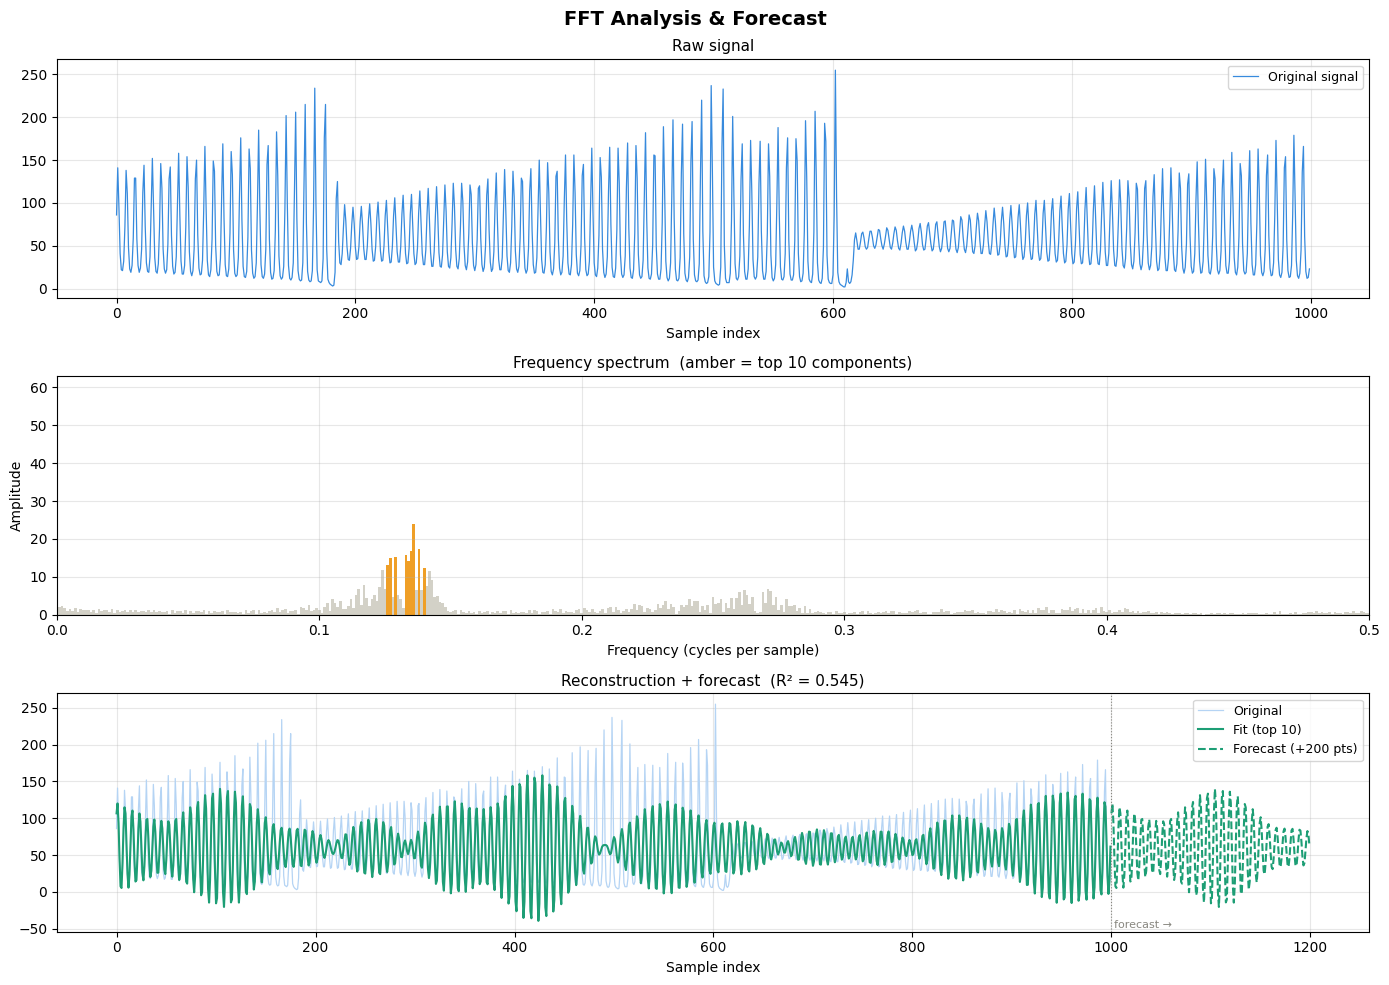


Plot saved to fft_analysis.png

R² vs. number of components (to help you pick TOP_N):
Components     R²
----------------------
1              0.0000
2              0.1302
3              0.1995
5              0.3213
8              0.4711
10             0.5451
15             0.6534
20             0.7075
30             0.7820
50             0.8623


In [4]:
import scipy.io
import torch
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load data ──────────────────────────────────────────────────────────────
data = scipy.io.loadmat('Xtrain.mat')
raw = data['Xtrain'].squeeze()          # shape: (N,)

# Convert to a float32 torch tensor
signal = torch.tensor(raw, dtype=torch.float32)
N = len(signal)
print(f"Loaded signal: {N} points  |  min={signal.min():.3f}  max={signal.max():.3f}")


# ── 2. Apply FFT ──────────────────────────────────────────────────────────────
fft_out   = torch.fft.rfft(signal)          # one-sided spectrum (N//2 + 1 bins)
amplitudes = fft_out.abs() / N              # normalise so amplitude matches real-world scale
amplitudes[1:-1] *= 2                       # double non-DC, non-Nyquist bins (one-sided correction)
phases     = torch.angle(fft_out)           # phase of each frequency component
freqs      = torch.fft.rfftfreq(N)          # frequency bins (cycles per sample)


# ── 3. Identify dominant frequencies ─────────────────────────────────────────
TOP_N = 10   # <── change this to see more or fewer components
top_idx = amplitudes.topk(TOP_N).indices.sort().values  # sorted by frequency, not amplitude

print(f"\nTop {TOP_N} frequency components:")
print(f"{'Rank':<6} {'Bin':<6} {'Cycles/window':<16} {'Amplitude':<12} {'Phase (rad)'}")
print("-" * 58)
for rank, idx in enumerate(amplitudes.topk(TOP_N).indices.tolist(), 1):
    f  = freqs[idx].item()
    a  = amplitudes[idx].item()
    ph = phases[idx].item()
    period = f"period ≈ {1/f:.1f} pts" if f > 0 else "DC offset"
    print(f"{rank:<6} {idx:<6} {f:<16.4f} {a:<12.4f} {ph:.4f}   ({period})")


# ── 4. Reconstruct signal from top-N components ───────────────────────────────
def reconstruct(n_components: int, length: int) -> torch.Tensor:
    """
    Reconstruct (and optionally extend) the signal using the top-n
    frequency components.  'length' can be > N to forecast future values.
    """
    top = amplitudes.topk(n_components).indices
    t   = torch.arange(length, dtype=torch.float32)
    out = torch.zeros(length)

    # DC component (bin 0)
    if 0 in top:
        out += amplitudes[0]

    # Sinusoidal components
    for idx in top:
        idx = idx.item()
        if idx == 0:
            continue
        f  = freqs[idx].item()
        a  = amplitudes[idx].item()
        ph = phases[idx].item()
        out += a * torch.cos(2 * torch.pi * f * t + ph)

    return out


# ── 5. Forecast ───────────────────────────────────────────────────────────────
FORECAST_STEPS = 200   # <── how many new points to predict beyond the data
total_len      = N + FORECAST_STEPS

recon_fit      = reconstruct(TOP_N, N)           # fit over original window
recon_forecast = reconstruct(TOP_N, total_len)   # extends naturally into future


# ── 6. Evaluate fit quality ───────────────────────────────────────────────────
mse  = torch.mean((signal - recon_fit) ** 2).item()
mae  = torch.mean((signal - recon_fit).abs()).item()
ss_res = torch.sum((signal - recon_fit) ** 2).item()
ss_tot = torch.sum((signal - signal.mean()) ** 2).item()
r2   = 1 - ss_res / ss_tot

print(f"\nFit quality (top {TOP_N} components over {N} points):")
print(f"  MSE : {mse:.4f}")
print(f"  MAE : {mae:.4f}")
print(f"  R²  : {r2:.4f}")


# ── 7. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("FFT Analysis & Forecast", fontsize=14, fontweight='bold')

# — Panel 1: raw signal
ax = axes[0]
ax.plot(signal.numpy(), color='#378ADD', linewidth=0.9, label='Original signal')
ax.set_title("Raw signal", fontsize=11)
ax.set_xlabel("Sample index")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# — Panel 2: frequency spectrum
ax = axes[1]
freq_np = freqs.numpy()
amp_np  = amplitudes.numpy()

# All bins in gray, top-N bins highlighted in amber
colors = ['#D3D1C7'] * len(amp_np)
for idx in amplitudes.topk(TOP_N).indices.tolist():
    colors[idx] = '#EF9F27'

ax.bar(freq_np, amp_np, width=freq_np[1] - freq_np[0] if len(freq_np) > 1 else 0.001,
       color=colors, linewidth=0)
ax.set_title(f"Frequency spectrum  (amber = top {TOP_N} components)", fontsize=11)
ax.set_xlabel("Frequency (cycles per sample)")
ax.set_ylabel("Amplitude")
ax.set_xlim(0, 0.5)
ax.grid(True, alpha=0.3)

# — Panel 3: reconstruction + forecast
ax = axes[2]
t_all    = np.arange(total_len)
t_orig   = np.arange(N)
t_future = np.arange(N, total_len)

ax.plot(t_orig,   signal.numpy(),                color='#B5D4F4', linewidth=0.9, label='Original')
ax.plot(t_orig,   recon_fit.numpy(),             color='#1D9E75', linewidth=1.5, label=f'Fit (top {TOP_N})')
ax.plot(t_future, recon_forecast[N:].numpy(),    color='#1D9E75', linewidth=1.5,
        linestyle='--', label=f'Forecast (+{FORECAST_STEPS} pts)')
ax.axvline(N, color='#888780', linewidth=0.8, linestyle=':')
ax.text(N + 3, ax.get_ylim()[0] * 0.9 if ax.get_ylim()[0] < 0 else ax.get_ylim()[1] * 0.9,
        'forecast →', fontsize=8, color='#888780')
ax.set_title(f"Reconstruction + forecast  (R² = {r2:.3f})", fontsize=11)
ax.set_xlabel("Sample index")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fft_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to fft_analysis.png")


# ── 8. Convenience helper: sweep TOP_N to find best fit ──────────────────────
print("\nR² vs. number of components (to help you pick TOP_N):")
print(f"{'Components':<14} {'R²'}")
print("-" * 22)
for n in [1, 2, 3, 5, 8, 10, 15, 20, 30, 50]:
    if n > len(amplitudes):
        break
    r = reconstruct(n, N)
    ss_r = torch.sum((signal - r) ** 2).item()
    print(f"{n:<14} {1 - ss_r/ss_tot:.4f}")

Raw shape from .mat file: (1000, 1)
dtype: uint8
Working shape: (1000,)

→ Univariate data: 1000 samples
  Running FFT-based frequency-band separation.

Detected 14 dominant frequency component(s):
  bin  105  freq=0.1050  amp=4.168  (period ≈ 9.5 pts)
  bin  112  freq=0.1120  amp=4.137  (period ≈ 8.9 pts)
  bin  117  freq=0.1170  amp=7.895  (period ≈ 8.5 pts)
  bin  124  freq=0.1240  amp=11.829  (period ≈ 8.1 pts)
  bin  129  freq=0.1290  amp=15.352  (period ≈ 7.8 pts)
  bin  136  freq=0.1360  amp=23.910  (period ≈ 7.4 pts)
  bin  142  freq=0.1420  amp=11.448  (period ≈ 7.0 pts)
  bin  232  freq=0.2320  amp=3.660  (period ≈ 4.3 pts)
  bin  241  freq=0.2410  amp=4.189  (period ≈ 4.1 pts)
  bin  250  freq=0.2500  amp=4.649  (period ≈ 4.0 pts)
  bin  257  freq=0.2570  amp=4.445  (period ≈ 3.9 pts)
  bin  262  freq=0.2620  amp=6.440  (period ≈ 3.8 pts)
  bin  271  freq=0.2710  amp=6.850  (period ≈ 3.7 pts)
  bin  278  freq=0.2780  amp=4.105  (period ≈ 3.6 pts)


/var/folders/_c/w0r7pp654p1g_b_47m7wrl0c0000gn/T/ipykernel_29158/3557478515.py:149: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(components))


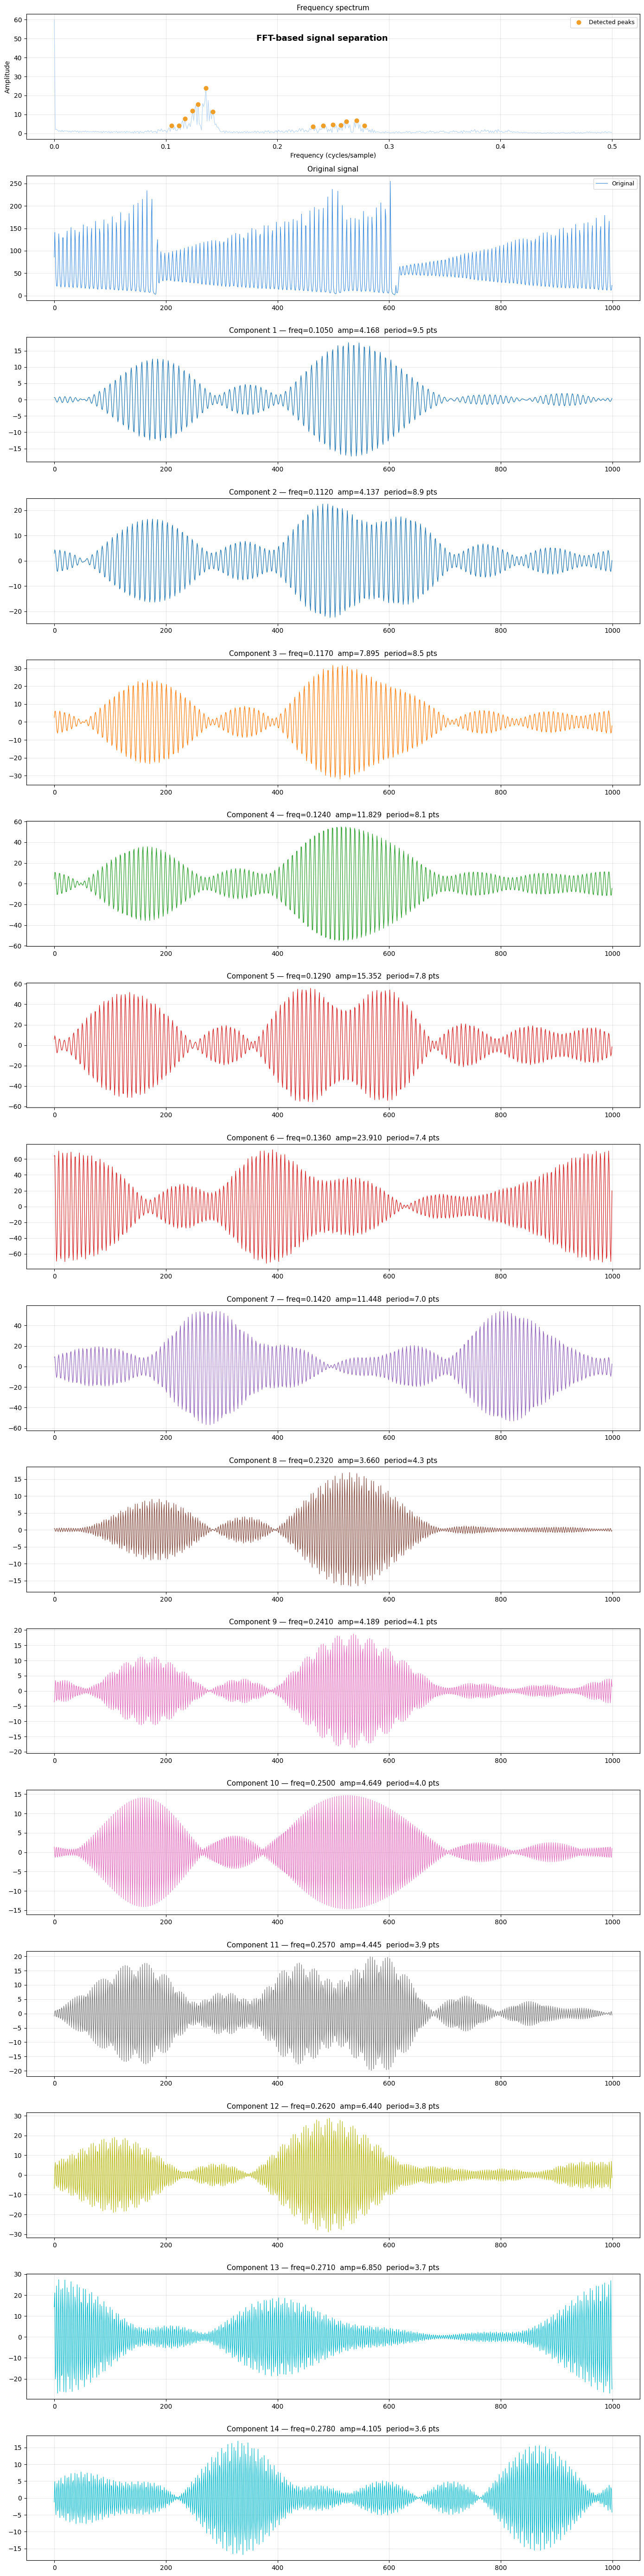


Saved: fft_separation.png

R² of 14 components vs original: -1.0531
(Residual std: 30.3390  — still some signal left)


In [5]:
import scipy.io
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── 1. Load & inspect ─────────────────────────────────────────────────────────
data  = scipy.io.loadmat('Xtrain.mat')
raw   = data['Xtrain']

print(f"Raw shape from .mat file: {raw.shape}")
print(f"dtype: {raw.dtype}")

# Squeeze only trailing size-1 dims so we don't accidentally flatten a 2D array
if raw.ndim == 2 and raw.shape[0] == 1:
    raw = raw.T           # (1, N) → (N, 1)
if raw.ndim == 2 and raw.shape[1] == 1:
    raw = raw.squeeze(1)  # (N, 1) → (N,)

print(f"Working shape: {raw.shape}")

is_multivariate = raw.ndim == 2 and raw.shape[1] > 1

# ── 2a. MULTIVARIATE PATH — plot each signal separately ──────────────────────
if is_multivariate:
    n_signals = raw.shape[1]
    N         = raw.shape[0]
    print(f"\n→ Multivariate data detected: {n_signals} signals × {N} samples")
    print("  The scatter plot you saw was all channels plotted on top of each other.")
    print("  Plotting each channel separately below.\n")

    signals = torch.tensor(raw, dtype=torch.float32)  # (N, n_signals)

    # — Individual channel plots
    cols  = 3
    rows  = int(np.ceil(n_signals / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3), sharex=True)
    axes  = np.array(axes).flatten()
    cmap  = cm.get_cmap('tab10', n_signals)

    for i in range(n_signals):
        ax = axes[i]
        ax.plot(signals[:, i].numpy(), linewidth=0.9, color=cmap(i))
        ax.set_title(f"Signal {i}", fontsize=10)
        ax.grid(True, alpha=0.25)
        ax.set_xlabel("Sample")
    for j in range(n_signals, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"All {n_signals} signals separated", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('signals_separated.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: signals_separated.png")

    # — Also overlay them with distinct colours (like your original but readable)
    fig2, ax2 = plt.subplots(figsize=(14, 5))
    for i in range(n_signals):
        ax2.plot(signals[:, i].numpy(), linewidth=0.8, alpha=0.75,
                 color=cmap(i), label=f"Signal {i}")
    ax2.set_title("All signals overlaid (coloured by channel)", fontsize=12)
    ax2.legend(fontsize=8, ncol=max(1, n_signals // 5),
               loc='upper right', framealpha=0.7)
    ax2.grid(True, alpha=0.25)
    ax2.set_xlabel("Sample")
    plt.tight_layout()
    plt.savefig('signals_overlaid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: signals_overlaid.png")

    # — Basic stats per channel
    print(f"\n{'Channel':<10} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
    print("-" * 52)
    for i in range(n_signals):
        s = signals[:, i]
        print(f"{i:<10} {s.mean().item():>10.3f} {s.std().item():>10.3f} "
              f"{s.min().item():>10.3f} {s.max().item():>10.3f}")


# ── 2b. UNIVARIATE PATH — FFT frequency-band separation ──────────────────────
else:
    N      = len(raw)
    signal = torch.tensor(raw.squeeze(), dtype=torch.float32)
    print(f"\n→ Univariate data: {N} samples")
    print("  Running FFT-based frequency-band separation.\n")

    # FFT
    fft_out    = torch.fft.rfft(signal)
    amplitudes = fft_out.abs() / N
    amplitudes[1:-1] *= 2
    freqs      = torch.fft.rfftfreq(N)

    # Auto-detect peaks in the spectrum via a simple prominence filter
    amp_np     = amplitudes.numpy()
    freq_np    = freqs.numpy()

    # Find local maxima with amplitude above a threshold
    threshold  = amp_np.max() * 0.05   # peaks > 5% of the tallest spike
    from scipy.signal import find_peaks
    peak_bins, props = find_peaks(amp_np, height=threshold, distance=5)

    print(f"Detected {len(peak_bins)} dominant frequency component(s):")
    for pk in peak_bins:
        period = f"period ≈ {1/freq_np[pk]:.1f} pts" if freq_np[pk] > 0 else "DC"
        print(f"  bin {pk:>4}  freq={freq_np[pk]:.4f}  amp={amp_np[pk]:.3f}  ({period})")

    def bandpass_extract(fft_coeffs, center_bin, half_width=3):
        """Zero out all bins except [center-half_width, center+half_width]."""
        mask = torch.zeros_like(fft_coeffs)
        lo   = max(0, center_bin - half_width)
        hi   = min(len(fft_coeffs), center_bin + half_width + 1)
        mask[lo:hi] = 1.0
        filtered = fft_coeffs * mask
        return torch.fft.irfft(filtered, n=N)

    # Separate each detected component
    components = []
    for pk in peak_bins:
        comp = bandpass_extract(fft_out, pk, half_width=4)
        components.append((pk, freq_np[pk], amp_np[pk], comp))

    # Residual = original minus sum of all extracted components
    residual = signal.clone()
    for _, _, _, comp in components:
        residual = residual - comp

    # — Plot: spectrum with detected peaks
    fig, axes = plt.subplots(2 + len(components), 1,
                             figsize=(14, 3.5 * (2 + len(components))))

    ax = axes[0]
    ax.plot(freq_np, amp_np, color='#B5D4F4', linewidth=0.8)
    ax.scatter(freq_np[peak_bins], amp_np[peak_bins],
               color='#EF9F27', zorder=5, s=40, label='Detected peaks')
    ax.set_title("Frequency spectrum", fontsize=11)
    ax.set_xlabel("Frequency (cycles/sample)")
    ax.set_ylabel("Amplitude")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # — Original signal
    ax = axes[1]
    ax.plot(signal.numpy(), color='#378ADD', linewidth=0.8, label='Original')
    ax.set_title("Original signal", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # — Each separated component
    cmap = cm.get_cmap('tab10', len(components))
    for i, (pk, freq, amp, comp) in enumerate(components):
        ax = axes[2 + i]
        period_str = f"{1/freq:.1f} pts" if freq > 0 else "DC"
        ax.plot(comp.numpy(), color=cmap(i), linewidth=0.9)
        ax.set_title(f"Component {i+1} — freq={freq:.4f}  amp={amp:.3f}  "
                     f"period≈{period_str}", fontsize=11)
        ax.grid(True, alpha=0.3)

    fig.suptitle("FFT-based signal separation", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fft_separation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved: fft_separation.png")

    # — Reconstruction quality
    recon = sum(c for _, _, _, c in components)
    ss_res = torch.sum((signal - recon) ** 2).item()
    ss_tot = torch.sum((signal - signal.mean()) ** 2).item()
    r2     = 1 - ss_res / ss_tot
    print(f"\nR² of {len(components)} components vs original: {r2:.4f}")
    print(f"(Residual std: {residual.std().item():.4f}  — "
          f"{'mostly noise' if residual.std() < signal.std() * 0.2 else 'still some signal left'})")

## 

Signal length: 1000

EEMD → 8 IMFs extracted
VMD   → 5 modes extracted


/var/folders/_c/w0r7pp654p1g_b_47m7wrl0c0000gn/T/ipykernel_29158/914704990.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', n_imfs)


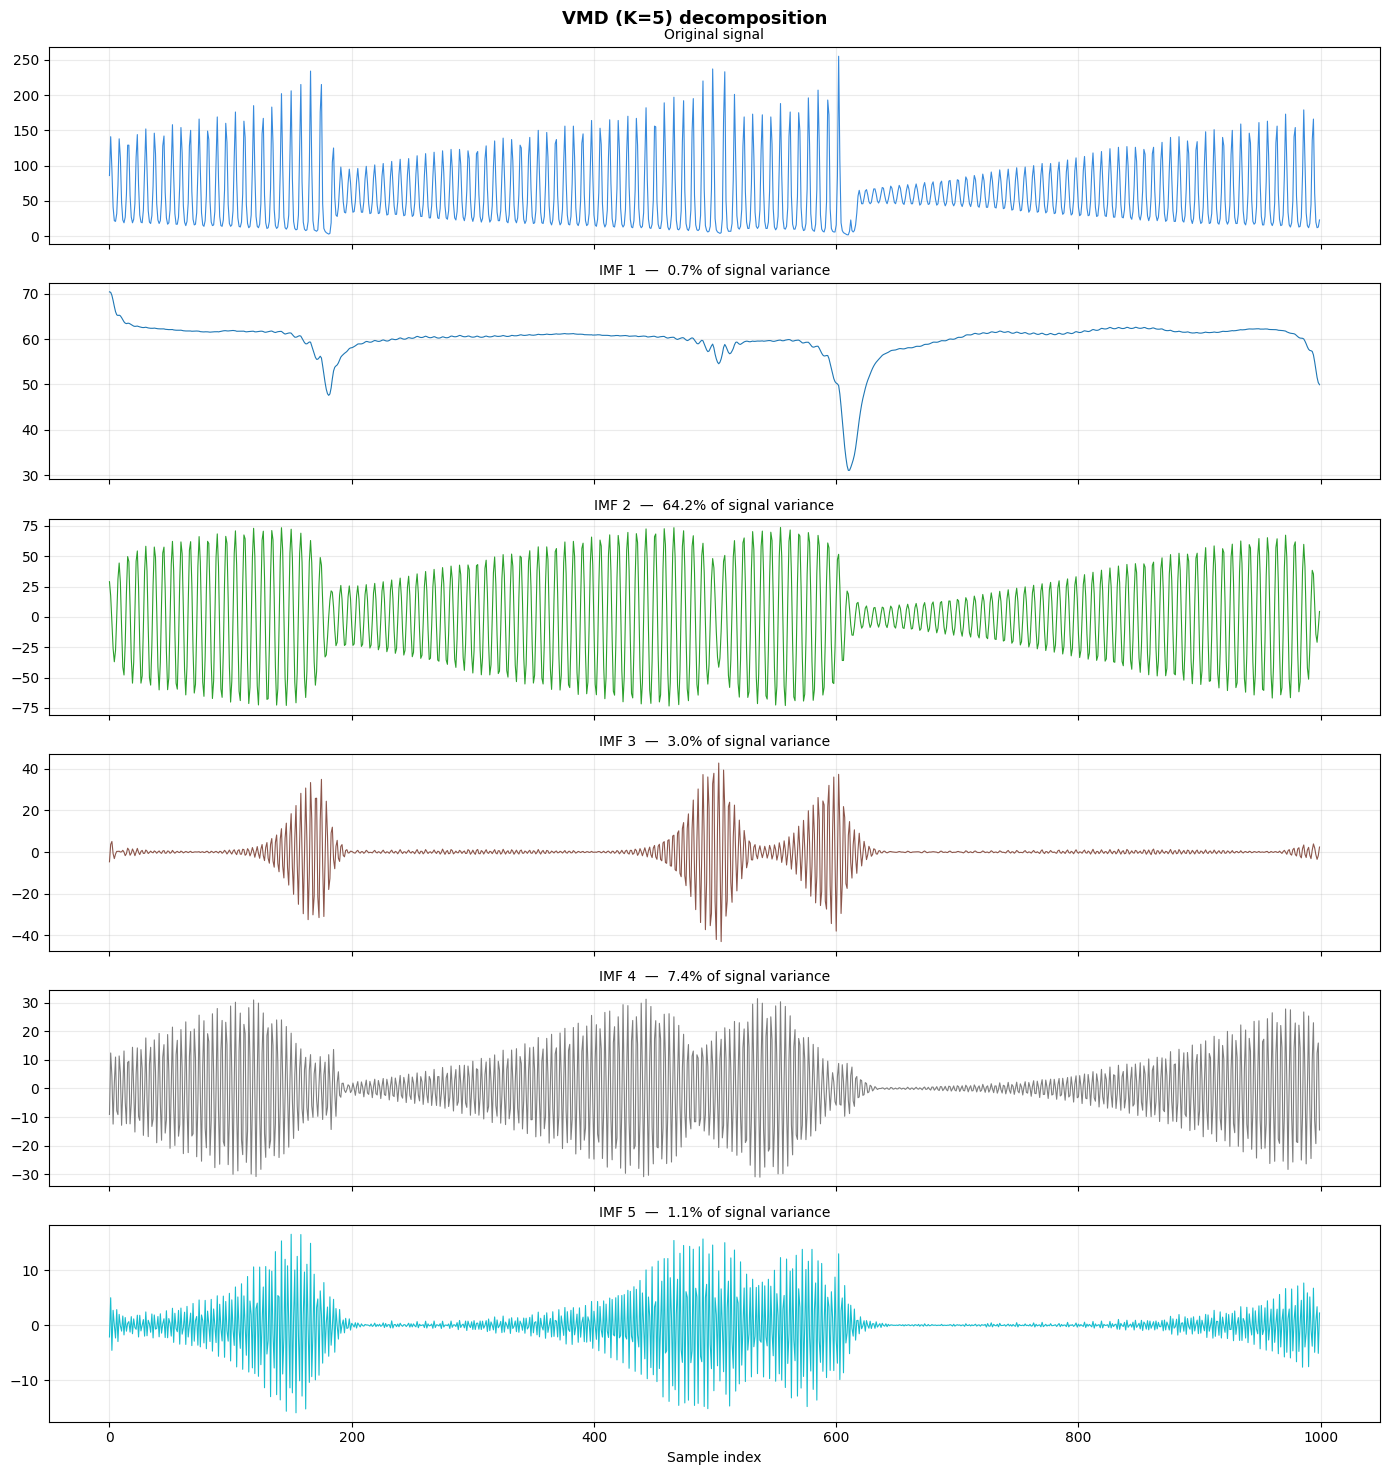


Saved: decomposition.png
Max reconstruction error: 9.45e+01  (slight numerical drift — normal for EEMD)

Dataset shapes → X: (970, 30, 6)  y: (970, 1)

Model parameters: 53,825
Input features per timestep: 6  (1 original + 5 IMFs)
Epoch  10/50  train=0.00335  val=0.00039
Epoch  20/50  train=0.00199  val=0.00037
Epoch  30/50  train=0.00106  val=0.00034
Epoch  40/50  train=0.00075  val=0.00025
Epoch  50/50  train=0.00069  val=0.00062

Test MAE : 4.2785
Test RMSE: 6.3104


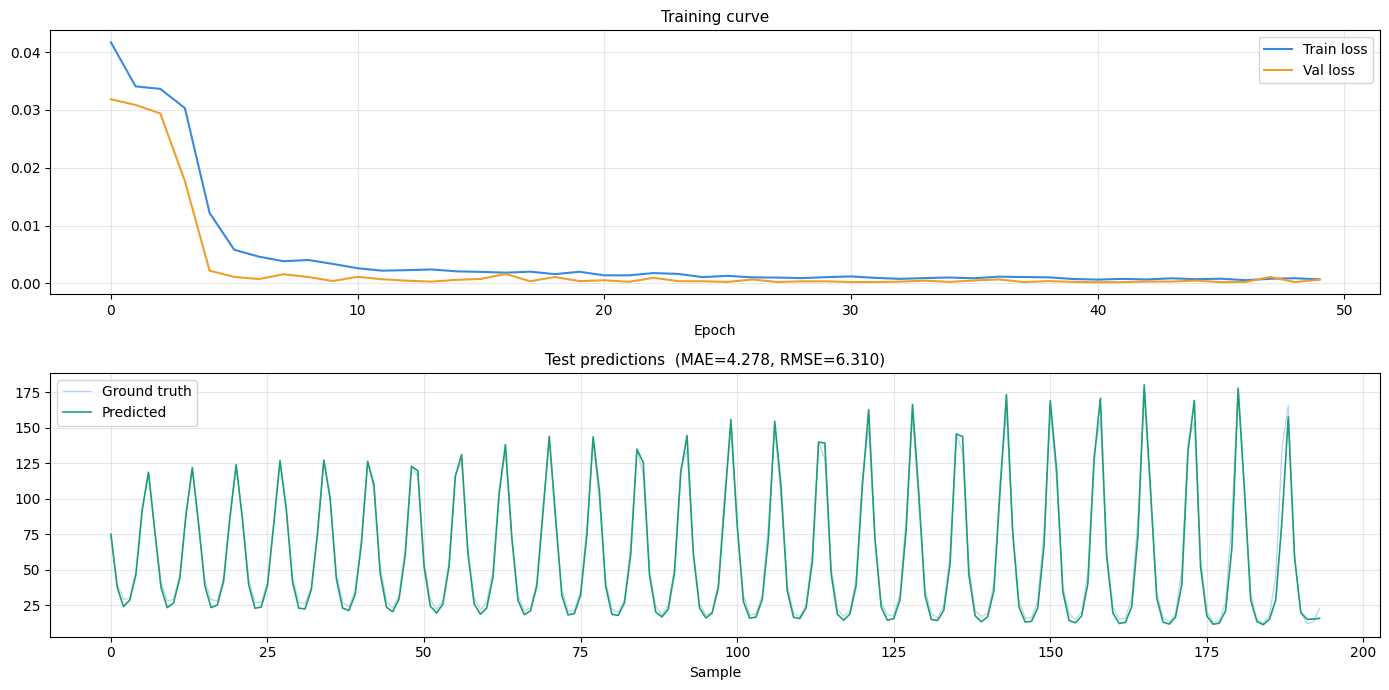

Saved: nn_predictions.png

Done.


In [9]:
"""
Signal decomposition via EMD / VMD + NN feature preparation
------------------------------------------------------------
Install deps:
    pip install EMD-signal vmdpy torch scikit-learn matplotlib scipy
"""
import scipy.io
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import MinMaxScaler

# ── 0. Load data ──────────────────────────────────────────────────────────────
data   = scipy.io.loadmat('Xtrain.mat')
signal = data['Xtrain'].squeeze().astype(np.float64)   # (1000,)
N      = len(signal)
print(f"Signal length: {N}")


# ══════════════════════════════════════════════════════════════════════════════
# PART 1 — Decomposition
# ══════════════════════════════════════════════════════════════════════════════

# ── 1a. EMD (Empirical Mode Decomposition) ────────────────────────────────────
# Adaptively splits signal into Intrinsic Mode Functions (IMFs).
# No parameters needed — fully data-driven.
try:
    from PyEMD import EEMD           # EEMD is more stable than plain EMD
    eemd = EEMD(trials=100, noise_width=0.05)
    eemd.logger.setLevel('ERROR')
    imfs_emd = eemd.eemd(signal)    # shape: (n_imfs, N)
    print(f"\nEEMD → {len(imfs_emd)} IMFs extracted")
    decomp_label = "EEMD"
    imfs = imfs_emd
except ImportError:
    print("PyEMD not installed: pip install EMD-signal")
    imfs_emd = None


# ── 1b. VMD (Variational Mode Decomposition) ─────────────────────────────────
# More robust than EMD; you specify the number of modes K up front.
# Recommended when you have a rough idea of how many waves are present.
try:
    from vmdpy import VMD

    K     = 5        # <── number of modes to extract (try 3–8)
    alpha = 2000     # bandwidth constraint (higher = narrower bands)
    tau   = 0.0      # noise tolerance
    DC    = 0        # no forced DC component
    init  = 1        # initialize omegas uniformly
    tol   = 1e-7

    imfs_vmd, _, _ = VMD(signal, alpha, tau, K, DC, init, tol)
    print(f"VMD   → {K} modes extracted")
except ImportError:
    print("vmdpy not installed: pip install vmdpy")
    imfs_vmd = None

# Use whichever succeeded (prefer VMD — usually cleaner modes)
if imfs_vmd is not None:
    imfs        = imfs_vmd
    decomp_label = f"VMD (K={K})"
elif imfs_emd is not None:
    imfs        = imfs_emd
    decomp_label = "EEMD"
else:
    raise RuntimeError("Install at least one of: EMD-signal, vmdpy")

n_imfs = len(imfs)


# ── 1c. Visualise decomposition ───────────────────────────────────────────────
fig, axes = plt.subplots(n_imfs + 1, 1, figsize=(14, 2.5 * (n_imfs + 1)),
                         sharex=True)
cmap = cm.get_cmap('tab10', n_imfs)
t    = np.arange(N)

axes[0].plot(t, signal, color='#378ADD', linewidth=0.8)
axes[0].set_title("Original signal", fontsize=10)
axes[0].grid(True, alpha=0.25)

for i, imf in enumerate(imfs):
    axes[i + 1].plot(t, imf, color=cmap(i), linewidth=0.8)
    var_pct = 100 * np.var(imf) / np.var(signal)
    axes[i + 1].set_title(f"IMF {i+1}  —  {var_pct:.1f}% of signal variance",
                           fontsize=10)
    axes[i + 1].grid(True, alpha=0.25)

axes[-1].set_xlabel("Sample index")
fig.suptitle(f"{decomp_label} decomposition", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: decomposition.png")

# Reconstruction sanity check
recon     = imfs.sum(axis=0)
recon_err = np.max(np.abs(signal - recon))
print(f"Max reconstruction error: {recon_err:.2e}  "
      f"({'✓ perfect' if recon_err < 1e-4 else 'slight numerical drift — normal for EEMD'})")


# ══════════════════════════════════════════════════════════════════════════════
# PART 2 — NN Feature Preparation  (Decompose → Forecast → Integrate)
# ══════════════════════════════════════════════════════════════════════════════

# ── 2a. Build sliding-window dataset ─────────────────────────────────────────
LOOKBACK  = 30    # <── how many past steps the model sees
HORIZON   = 1     # <── how many steps ahead to predict
TRAIN_PCT = 0.8

def make_windows(series_2d: np.ndarray, lookback: int, horizon: int):
    """
    series_2d : (n_features, T)  — original signal + all IMFs stacked
    Returns X (n_samples, lookback, n_features) and y (n_samples, horizon)
    where y is the ORIGINAL signal (index 0) shifted by horizon.
    """
    T          = series_2d.shape[1]
    n_features = series_2d.shape[0]
    X_list, y_list = [], []
    for i in range(lookback, T - horizon + 1):
        X_list.append(series_2d[:, i - lookback:i].T)   # (lookback, n_features)
        y_list.append(series_2d[0, i:i + horizon])       # original signal as target
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

# Stack: row 0 = original signal, rows 1..n_imfs = IMFs
# This gives the NN both the raw signal history AND each decomposed component
stacked = np.vstack([signal[np.newaxis, :], imfs])  # (n_imfs+1, N)

# Scale each feature independently to [0, 1]
scalers = []
stacked_scaled = np.empty_like(stacked)
for i in range(stacked.shape[0]):
    sc = MinMaxScaler()
    stacked_scaled[i] = sc.fit_transform(stacked[i].reshape(-1, 1)).squeeze()
    scalers.append(sc)

X, y = make_windows(stacked_scaled, LOOKBACK, HORIZON)
print(f"\nDataset shapes → X: {X.shape}  y: {y.shape}")

split    = int(len(X) * TRAIN_PCT)
X_train  = torch.tensor(X[:split])
y_train  = torch.tensor(y[:split])
X_test   = torch.tensor(X[split:])
y_test   = torch.tensor(y[split:])

train_dl = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)


# ── 2b. Simple LSTM that ingests all IMFs as features ─────────────────────────
class IMF_LSTM(nn.Module):
    def __init__(self, n_features, hidden=64, layers=2, horizon=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, layers,
                            batch_first=True, dropout=0.2)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, horizon)
        )

    def forward(self, x):               # x: (B, lookback, n_features)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]) # take last timestep

n_feat = stacked_scaled.shape[0]       # original + n_imfs
model  = IMF_LSTM(n_features=n_feat, hidden=64, layers=2, horizon=HORIZON)
opt    = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input features per timestep: {n_feat}  "
      f"(1 original + {n_imfs} IMFs)")


# ── 2c. Training loop ─────────────────────────────────────────────────────────
EPOCHS = 50
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for xb, yb in train_dl:
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_test), y_test).item()

    train_losses.append(np.mean(batch_losses))
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  "
              f"train={train_losses[-1]:.5f}  val={val_losses[-1]:.5f}")


# ── 2d. Evaluate & plot predictions ──────────────────────────────────────────
model.eval()
with torch.no_grad():
    preds_scaled = model(X_test).numpy().squeeze()

# Invert scaling on predictions and ground truth (both are on original signal scaler)
sc0     = scalers[0]
preds   = sc0.inverse_transform(preds_scaled.reshape(-1, 1)).squeeze()
gt      = sc0.inverse_transform(y_test.numpy().reshape(-1, 1)).squeeze()

mae  = np.mean(np.abs(preds - gt))
rmse = np.sqrt(np.mean((preds - gt) ** 2))
print(f"\nTest MAE : {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

ax1.plot(train_losses, label='Train loss', color='#378ADD')
ax1.plot(val_losses,   label='Val loss',   color='#EF9F27')
ax1.set_title("Training curve", fontsize=11)
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

show = min(300, len(gt))
ax2.plot(gt[:show],    color='#B5D4F4', linewidth=0.9, label='Ground truth')
ax2.plot(preds[:show], color='#1D9E75', linewidth=1.2, label='Predicted')
ax2.set_title(f"Test predictions  (MAE={mae:.3f}, RMSE={rmse:.3f})", fontsize=11)
ax2.set_xlabel("Sample")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nn_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nn_predictions.png")
print("\nDone.")

## self-made version

Signal length : 1000 datapoints
N_WAVES       : 7
Points/wave   : ~142 (last wave may have 6 fewer points)


/var/folders/_c/w0r7pp654p1g_b_47m7wrl0c0000gn/T/ipykernel_62710/3792425873.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', N_WAVES)


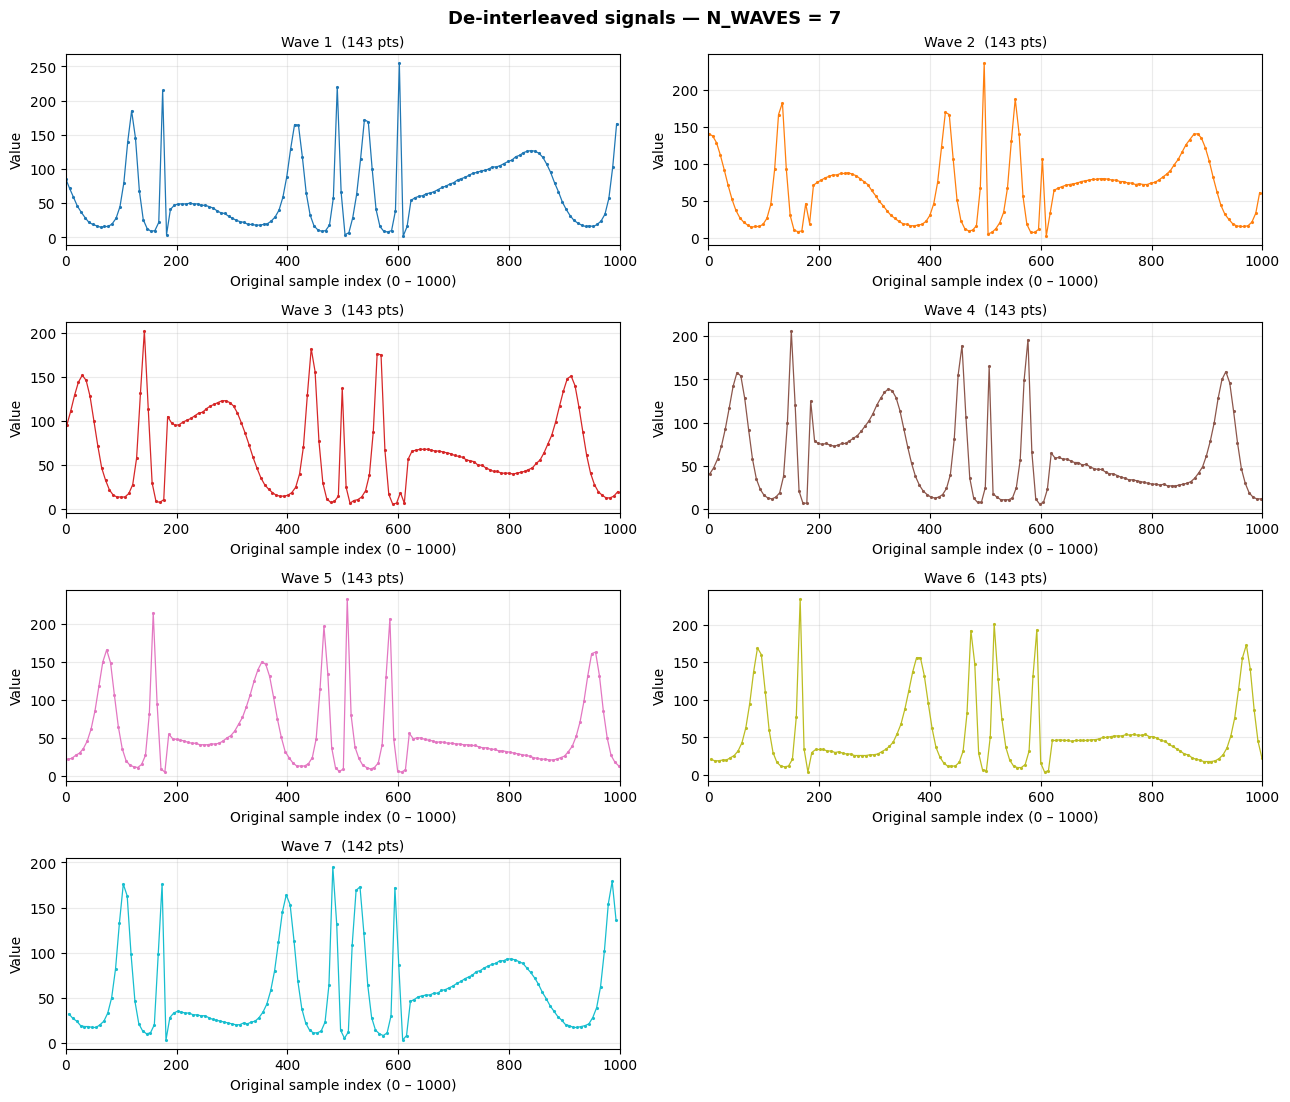

Saved: waves_separate_n7.png


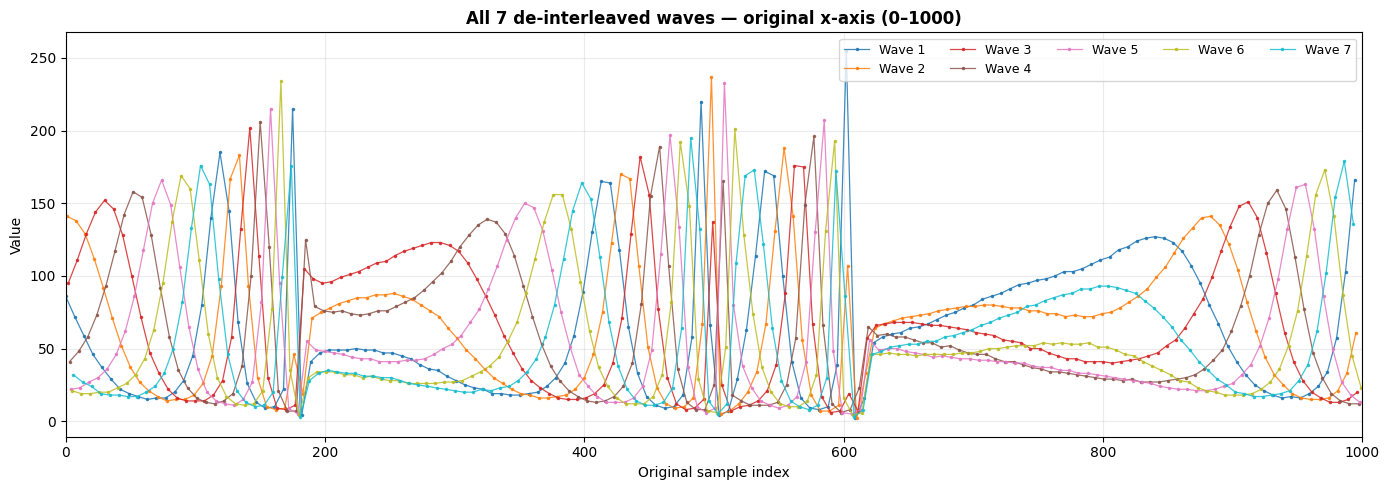

Saved: waves_overlay_n7.png

Wave     N pts         Mean       Std       Min       Max
───────────────────────────────────────────────────────
1        143         62.888    49.510     2.000   255.000
2        143         65.035    44.811     2.000   237.000
3        143         65.748    46.093     6.000   202.000
4        143         61.329    46.529     6.000   206.000
5        143         54.944    47.039     5.000   233.000
6        143         52.692    46.216     4.000   234.000
7        142         56.599    45.922     3.000   195.000

Original std       : 46.852
Mean per-wave std  : 46.589
→ Per-wave std is similar to original — try a different N_WAVES value.


In [25]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Settings ──────────────────────────────────────────────────────────────────
N_WAVES    = 7       # <── change this: try 2, 3, 4, 5, 6, 7, 8 ...
PLOT_MODE  = "both"  # "separate" | "overlay" | "both"
# ─────────────────────────────────────────────────────────────────────────────

# ── Load ──────────────────────────────────────────────────────────────────────
data   = scipy.io.loadmat('Xtrain.mat')
signal = data['Xtrain'].squeeze()
N      = len(signal)
print(f"Signal length : {N} datapoints")
print(f"N_WAVES       : {N_WAVES}")
print(f"Points/wave   : ~{N // N_WAVES} (last wave may have {N % N_WAVES} fewer points)")

# ── De-interleave ─────────────────────────────────────────────────────────────
# Wave i gets indices i, i+N_WAVES, i+2*N_WAVES, ...
# We store both the original indices AND the values so we can plot on
# the full 0–N x-axis for easy comparison with the original signal.
cmap = cm.get_cmap('tab10', N_WAVES)

waves = []
for i in range(N_WAVES):
    indices = np.arange(i, N, N_WAVES)
    waves.append((indices, signal[indices]))

# ── Plot: separate subplots (each wave on its own compressed x-axis) ──────────
if PLOT_MODE in ("separate", "both"):
    cols  = min(2, N_WAVES)
    rows  = int(np.ceil(N_WAVES / cols))
    fig, axes = plt.subplots(rows, cols,
                             figsize=(13, 2.8 * rows),
                             sharex=False)
    axes = np.array(axes).flatten()

    for i, (idx, wave) in enumerate(waves):
        ax = axes[i]
        ax.plot(idx, wave, color=cmap(i), linewidth=0.9,
                marker='.', markersize=2.5)
        ax.set_title(f"Wave {i+1}  ({len(wave)} pts)", fontsize=10)
        ax.set_xlabel("Original sample index (0 – 1000)")
        ax.set_ylabel("Value")
        ax.set_xlim(0, N)
        ax.grid(True, alpha=0.25)

    for j in range(N_WAVES, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"De-interleaved signals — N_WAVES = {N_WAVES}",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'waves_separate_n{N_WAVES}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: waves_separate_n{N_WAVES}.png")

# ── Plot: overlay on the original 0–N x-axis ─────────────────────────────────
# Each wave is plotted at its actual positions in the original signal,
# so the x-axis always spans 0–1000 and regions align across waves.
if PLOT_MODE in ("overlay", "both"):
    fig, ax = plt.subplots(figsize=(14, 5))

    for i, (idx, wave) in enumerate(waves):
        ax.plot(idx, wave, color=cmap(i), linewidth=0.9,
                alpha=0.85, label=f"Wave {i+1}",
                marker='.', markersize=3)

    ax.set_xlim(0, N)
    ax.set_title(f"All {N_WAVES} de-interleaved waves — original x-axis (0–{N})",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Original sample index")
    ax.set_ylabel("Value")
    ax.legend(fontsize=9, ncol=min(N_WAVES, 5),
              loc='upper right', framealpha=0.8)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(f'waves_overlay_n{N_WAVES}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: waves_overlay_n{N_WAVES}.png")

# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"\n{'Wave':<8} {'N pts':<8} {'Mean':>9} {'Std':>9} {'Min':>9} {'Max':>9}")
print("─" * 55)
for i, (idx, wave) in enumerate(waves):
    print(f"{i+1:<8} {len(wave):<8} {wave.mean():>9.3f} "
          f"{wave.std():>9.3f} {wave.min():>9.3f} {wave.max():>9.3f}")

orig_std  = signal.std()
waves_std = np.mean([w.std() for _, w in waves])
print(f"\nOriginal std       : {orig_std:.3f}")
print(f"Mean per-wave std  : {waves_std:.3f}")
if waves_std < orig_std * 0.85:
    print("→ Per-wave std is lower than original — de-interleaving likely reveals real structure!")
else:
    print("→ Per-wave std is similar to original — try a different N_WAVES value.")